# **XGBoost for Student Performance Prediction**

In [1]:
!pip install kagglehub
import kagglehub
import pandas as pd

path = kagglehub.dataset_download("rahulchauhan016/student-behavior-and-performance-dataset")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Samay\.cache\kagglehub\datasets\rahulchauhan016\student-behavior-and-performance-dataset\versions\2


In [2]:
import os

files = os.listdir(path)
print(files)

['activity_logs.csv', 'exams.csv', 'students.csv', 'student_behavior_dataset.csv', 'test.csv', 'train.csv']


In [3]:
import pandas as pd

df_behavior = pd.read_csv(os.path.join(path, "student_behavior_dataset.csv"))
df_behavior.head()

,student_id,hours_studied,attendance,assignments_completed,sleep_hours,social_media_time,final_score
0,1,3.745401,NaN,0,7.509599,2.160708,33.023777
1,2,9.507143,59.225600,19,6.724484,4.518279,93.756929
2,3,7.319939,NaN,2,6.072127,1.354612,67.220865
3,4,5.986585,83.164032,12,7.690965,1.624239,79.900361
4,5,1.560186,74.104467,6,8.673757,3.445608,44.721586


In [4]:
df_students = pd.read_csv(os.path.join(path, "students.csv"))
df_students.head()

,student_id,age,gender,baseline_intelligence
0,1,22,Female,82.600891
1,2,19,Female,109.033979
2,3,23,Male,83.787742
3,4,20,Female,116.742532
4,5,22,Male,94.551293


In [5]:
df_raw = pd.merge(df_behavior, df_students, on="student_id")
df_raw.head()

,student_id,hours_studied,attendance,assignments_completed,sleep_hours,social_media_time,final_score,age,gender,baseline_intelligence
0,1,3.745401,NaN,0,7.509599,2.160708,33.023777,22,Female,82.600891
1,2,9.507143,59.225600,19,6.724484,4.518279,93.756929,19,Female,109.033979
2,3,7.319939,NaN,2,6.072127,1.354612,67.220865,23,Male,83.787742
3,4,5.986585,83.164032,12,7.690965,1.624239,79.900361,20,Female,116.742532
4,5,1.560186,74.104467,6,8.673757,3.445608,44.721586,22,Male,94.551293


In [6]:
df_raw.shape

(10000, 10)

In [7]:
df_raw.isnull().sum()

student_id                 0
hours_studied            479
attendance               503
assignments_completed      0
sleep_hours              513
social_media_time          0
final_score                0
age                        0
gender                     0
baseline_intelligence      0
dtype: int64

In [8]:
df = df_raw.dropna()
df.shape

(8574, 10)

In [9]:
df.head()

,student_id,hours_studied,attendance,assignments_completed,sleep_hours,social_media_time,final_score,age,gender,baseline_intelligence
1,2,9.507143,59.225600,19,6.724484,4.518279,93.756929,19,Female,109.033979
3,4,5.986585,83.164032,12,7.690965,1.624239,79.900361,20,Female,116.742532
4,5,1.560186,74.104467,6,8.673757,3.445608,44.721586,22,Male,94.551293
6,7,0.580836,98.060395,5,6.923164,3.935994,37.658549,22,Male,77.900960
7,8,8.661761,55.827334,1,5.035172,4.741843,47.253336,23,Female,112.356394


## **Data split**

In [10]:
X = df.drop(columns=["final_score", "student_id"])  # features
y = df["final_score"]  # target

In [11]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## **Model development**

In [12]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error

In [13]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
X_train['gender'] = le.fit_transform(X_train['gender'])
X_test['gender'] = le.transform(X_test['gender'])

In [14]:
model = XGBRegressor(n_estimators=100,learning_rate=0.1,max_depth=4,random_state=42)
model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


## **Model evaluation**

In [15]:
y_pred = model.predict(X_test)

In [16]:
import numpy as np
from sklearn.metrics import mean_squared_error,r2_score

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("RMSE:", rmse)

RMSE: 5.234061258304872


In [17]:
r2 = r2_score(y_test, y_pred)
print("R2:", r2)

R2: 0.9268866822218574


In [18]:
tolerance = 5

accuracy = np.mean(np.abs(y_test - y_pred) <= tolerance)
print("Accuracy within ±5:", accuracy)

Accuracy within ±5: 0.6553935860058309


## **Data visualization**

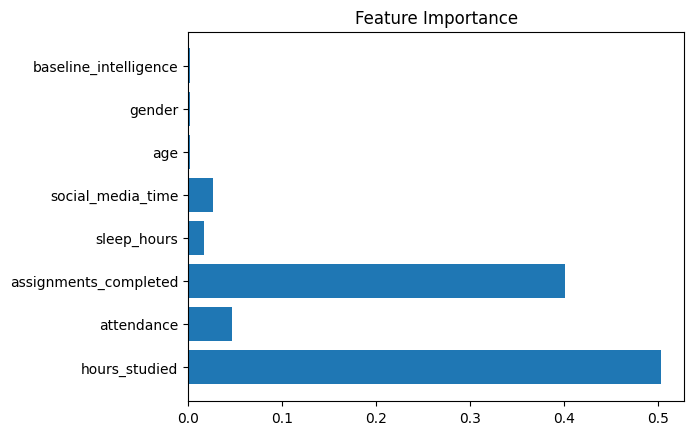

In [19]:
import matplotlib.pyplot as plt

importances = model.feature_importances_
features = X.columns

plt.barh(features, importances)
plt.title("Feature Importance")
plt.show()

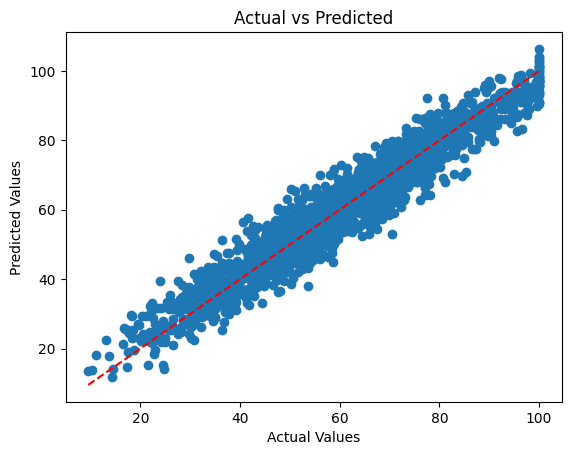

In [20]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")

# línea perfecta
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle='--',color='red')

plt.show()

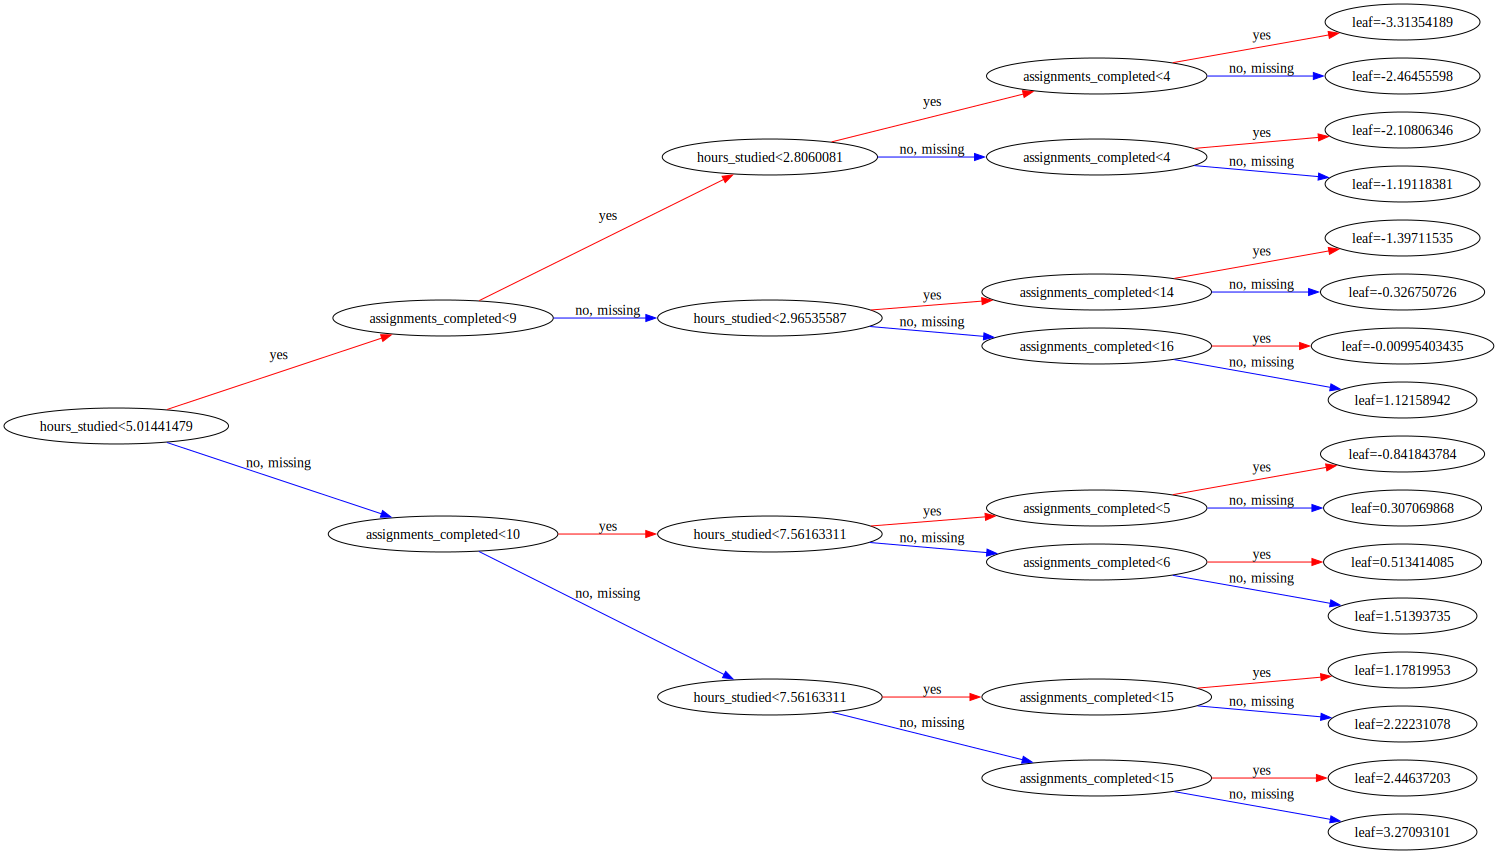

In [29]:

from xgboost import to_graphviz

graph = to_graphviz(model, tree_idx=0, rankdir='LR')
graph.render('complete_tree', format='png', cleanup=True)
graph